# TP 6 - Regresión

## Predecir retrasos en los vuelos
El dataset contiene 400.000+ registros, cada uno con 21 atributos, de vuelos realizados entre el 1/1/19 y el 31/1/19. El objetivo es predecir las demoras o retrasos de un vuelo en particular.ctWNF

In [1]:
import numpy as np
import pandas as pd
import os
import requests
import time
import re
import string
from urllib.parse import urlparse


from tqdm import tqdm
from dataclasses import dataclass
from typing import List, Tuple, Dict, Optional
from glob import glob
from pathlib import Path


import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from scipy import stats
from scipy.stats import pearsonr, spearmanr
import statsmodels.api as sm

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.model_selection import RandomizedSearchCV

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.model_selection import StratifiedKFold
from sklearn.svm import SVC


from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    mean_squared_error,
    r2_score,
    average_precision_score,
    precision_recall_curve
)

import umap

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer


from joblib import dump, load
import warnings

warnings.filterwarnings("ignore")

C:\Users\pablonicolasr\anaconda3\envs\am_uns\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
path_data = os.path.join(os.getcwd(), "data")
path = Path(path_data)
path.mkdir(parents=True, exist_ok=True)

In [ ]:
urls = [
    "https://raw.githubusercontent.com/emmanueliarussi/DataScienceCapstone/master/3_MidtermProjects/ProjectFD/data/jan_2019_ontime.csv",
    "https://raw.githubusercontent.com/emmanueliarussi/DataScienceCapstone/master/3_MidtermProjects/ProjectFD/data/jan_2020_ontime.csv",
]

for url in urls:

    output_path = os.path.join(path_data, os.path.basename(urlparse(url).path))
    
    start_time = time.time()
    
    response = requests.get(url, stream=True)
    response.raise_for_status()
    
    total_size = int(response.headers.get("content-length", 0))
    chunk_size = 8192
    
    with open(output_path, "wb") as f, tqdm(
        total=total_size,
        unit="B",
        unit_scale=True,
        desc="Downloading dataset"
    ) as pbar:
        for chunk in response.iter_content(chunk_size=chunk_size):
            if chunk:
                f.write(chunk)
                pbar.update(len(chunk))
    
    elapsed = time.time() - start_time
    print(f"\nDownload completed in {elapsed:.2f} seconds")

In [3]:
df1 = pd.read_csv(os.path.join(os.getcwd(), "data", "jan_2019_ontime.csv"))
df2 = pd.read_csv(os.path.join(os.getcwd(), "data", "jan_2020_ontime.csv"))

In [4]:
df1.head()

,DAY_OF_MONTH,DAY_OF_WEEK,OP_UNIQUE_CARRIER,OP_CARRIER_AIRLINE_ID,OP_CARRIER,TAIL_NUM,OP_CARRIER_FL_NUM,ORIGIN_AIRPORT_ID,ORIGIN_AIRPORT_SEQ_ID,ORIGIN,...,DEST,DEP_TIME,DEP_DEL15,DEP_TIME_BLK,ARR_TIME,ARR_DEL15,CANCELLED,DIVERTED,DISTANCE,Unnamed: 21
0,1,2,9E,20363,9E,N8688C,3280,11953,1195302,GNV,...,ATL,601.0,0.0,0600-0659,722.0,0.0,0.0,0.0,300.0,NaN
1,1,2,9E,20363,9E,N348PQ,3281,13487,1348702,MSP,...,CVG,1359.0,0.0,1400-1459,1633.0,0.0,0.0,0.0,596.0,NaN
2,1,2,9E,20363,9E,N8896A,3282,11433,1143302,DTW,...,CVG,1215.0,0.0,1200-1259,1329.0,0.0,0.0,0.0,229.0,NaN
3,1,2,9E,20363,9E,N8886A,3283,15249,1524906,TLH,...,ATL,1521.0,0.0,1500-1559,1625.0,0.0,0.0,0.0,223.0,NaN
4,1,2,9E,20363,9E,N8974C,3284,10397,1039707,ATL,...,FSM,1847.0,0.0,1900-1959,1940.0,0.0,0.0,0.0,579.0,NaN


In [5]:
df2.head()

,DAY_OF_MONTH,DAY_OF_WEEK,OP_UNIQUE_CARRIER,OP_CARRIER_AIRLINE_ID,OP_CARRIER,TAIL_NUM,OP_CARRIER_FL_NUM,ORIGIN_AIRPORT_ID,ORIGIN_AIRPORT_SEQ_ID,ORIGIN,...,DEST,DEP_TIME,DEP_DEL15,DEP_TIME_BLK,ARR_TIME,ARR_DEL15,CANCELLED,DIVERTED,DISTANCE,Unnamed: 21
0,1,3,EV,20366,EV,N48901,4397,13930,1393007,ORD,...,GRB,1003.0,0.0,1000-1059,1117.0,0.0,0.0,0.0,174.0,NaN
1,1,3,EV,20366,EV,N16976,4401,15370,1537002,TUL,...,ORD,1027.0,0.0,1000-1059,1216.0,0.0,0.0,0.0,585.0,NaN
2,1,3,EV,20366,EV,N12167,4404,11618,1161802,EWR,...,TYS,1848.0,0.0,1800-1859,2120.0,0.0,0.0,0.0,631.0,NaN
3,1,3,EV,20366,EV,N14902,4405,10781,1078105,BTR,...,IAH,1846.0,0.0,1800-1859,2004.0,0.0,0.0,0.0,253.0,NaN
4,1,3,EV,20366,EV,N606UX,4407,14524,1452401,RIC,...,IAH,1038.0,0.0,1000-1059,1330.0,0.0,0.0,0.0,1157.0,NaN


In [6]:
assert set(df1.columns) == set(df2.columns)

In [7]:
df = pd.concat([df1, df2])
df.head()

,DAY_OF_MONTH,DAY_OF_WEEK,OP_UNIQUE_CARRIER,OP_CARRIER_AIRLINE_ID,OP_CARRIER,TAIL_NUM,OP_CARRIER_FL_NUM,ORIGIN_AIRPORT_ID,ORIGIN_AIRPORT_SEQ_ID,ORIGIN,...,DEST,DEP_TIME,DEP_DEL15,DEP_TIME_BLK,ARR_TIME,ARR_DEL15,CANCELLED,DIVERTED,DISTANCE,Unnamed: 21
0,1,2,9E,20363,9E,N8688C,3280,11953,1195302,GNV,...,ATL,601.0,0.0,0600-0659,722.0,0.0,0.0,0.0,300.0,NaN
1,1,2,9E,20363,9E,N348PQ,3281,13487,1348702,MSP,...,CVG,1359.0,0.0,1400-1459,1633.0,0.0,0.0,0.0,596.0,NaN
2,1,2,9E,20363,9E,N8896A,3282,11433,1143302,DTW,...,CVG,1215.0,0.0,1200-1259,1329.0,0.0,0.0,0.0,229.0,NaN
3,1,2,9E,20363,9E,N8886A,3283,15249,1524906,TLH,...,ATL,1521.0,0.0,1500-1559,1625.0,0.0,0.0,0.0,223.0,NaN
4,1,2,9E,20363,9E,N8974C,3284,10397,1039707,ATL,...,FSM,1847.0,0.0,1900-1959,1940.0,0.0,0.0,0.0,579.0,NaN


In [8]:
df.columns

Index(['DAY_OF_MONTH', 'DAY_OF_WEEK', 'OP_UNIQUE_CARRIER',
       'OP_CARRIER_AIRLINE_ID', 'OP_CARRIER', 'TAIL_NUM', 'OP_CARRIER_FL_NUM',
       'ORIGIN_AIRPORT_ID', 'ORIGIN_AIRPORT_SEQ_ID', 'ORIGIN',
       'DEST_AIRPORT_ID', 'DEST_AIRPORT_SEQ_ID', 'DEST', 'DEP_TIME',
       'DEP_DEL15', 'DEP_TIME_BLK', 'ARR_TIME', 'ARR_DEL15', 'CANCELLED',
       'DIVERTED', 'DISTANCE', 'Unnamed: 21'],
      dtype='str')

In [9]:
df = df.drop(columns=["Unnamed: 21"])

In [10]:
df.columns

Index(['DAY_OF_MONTH', 'DAY_OF_WEEK', 'OP_UNIQUE_CARRIER',
       'OP_CARRIER_AIRLINE_ID', 'OP_CARRIER', 'TAIL_NUM', 'OP_CARRIER_FL_NUM',
       'ORIGIN_AIRPORT_ID', 'ORIGIN_AIRPORT_SEQ_ID', 'ORIGIN',
       'DEST_AIRPORT_ID', 'DEST_AIRPORT_SEQ_ID', 'DEST', 'DEP_TIME',
       'DEP_DEL15', 'DEP_TIME_BLK', 'ARR_TIME', 'ARR_DEL15', 'CANCELLED',
       'DIVERTED', 'DISTANCE'],
      dtype='str')

## Antes de realizar un Análisis Exploratorio debemos realizar checks de consistencia

In [11]:
SEED = 42
TARGET = "DEP_DEL15"

In [12]:
# sanity: target binario
assert set(df[TARGET].dropna().unique()).issubset({0,1}), "DEP_DEL15 no es binario 0/1"

In [13]:
# rangos básicos
assert df["DAY_OF_WEEK"].between(1,7).all(), "DAY_OF_WEEK fuera de [1,7]"
assert df["DAY_OF_MONTH"].between(1,31).all(), "DAY_OF_MONTH fuera de [1,31]"
assert (df["DISTANCE"] >= 0).all(), "DISTANCE negativa"

## Análisis de valores faltantes

In [14]:
missing_pct = (df.isna().mean()*100).sort_values(ascending=False)
display(missing_pct[missing_pct>0])

ARR_DEL15    2.190827
ARR_TIME     2.025969
DEP_DEL15    1.935146
DEP_TIME     1.931957
TAIL_NUM     0.272049
dtype: float64

In [15]:
dep_time_missing = df["DEP_TIME"].isna().astype(int)
cancelled = df["CANCELLED"].fillna(0).astype(int)

tmp = pd.DataFrame({"dep_missing": dep_time_missing, "cancelled": cancelled})

counts = (
    tmp.groupby(["dep_missing", "cancelled"])
       .size()
       .unstack(fill_value=0)
)

props = counts.div(counts.sum(axis=1), axis=0)

# renombres robustos
counts = counts.rename(index={0:"DEP_TIME presente", 1:"DEP_TIME faltante"},
                       columns={0:"CANCELLED=0", 1:"CANCELLED=1"})
props  = props.rename(index={0:"DEP_TIME presente", 1:"DEP_TIME faltante"},
                      columns={0:"CANCELLED=0", 1:"CANCELLED=1"})

display(counts)
display(props)

cancelled,CANCELLED=0,CANCELLED=1
dep_missing,,
DEP_TIME presente,1167677,638
DEP_TIME faltante,0,23016


cancelled,CANCELLED=0,CANCELLED=1
dep_missing,,
DEP_TIME presente,0.999454,0.000546
DEP_TIME faltante,0.000000,1.000000


In [16]:
df[(df["CANCELLED"]==1) & (df["DEP_TIME"].notna())].head()

,DAY_OF_MONTH,DAY_OF_WEEK,OP_UNIQUE_CARRIER,OP_CARRIER_AIRLINE_ID,OP_CARRIER,TAIL_NUM,OP_CARRIER_FL_NUM,ORIGIN_AIRPORT_ID,ORIGIN_AIRPORT_SEQ_ID,ORIGIN,...,DEST_AIRPORT_SEQ_ID,DEST,DEP_TIME,DEP_DEL15,DEP_TIME_BLK,ARR_TIME,ARR_DEL15,CANCELLED,DIVERTED,DISTANCE
971,1,2,OH,20397,OH,N572NN,5103,11057,1105703,CLT,...,1419306,PNS,1953.0,0.0,1900-1959,NaN,NaN,1.0,0.0,488.0
2018,1,2,EV,20366,EV,N13992,4242,12266,1226603,IAH,...,1501606,STL,1829.0,0.0,1800-1859,NaN,NaN,1.0,0.0,667.0
3222,1,2,OO,20304,OO,N750EV,3048,13930,1393007,ORD,...,1385103,OKC,1658.0,1.0,1300-1359,NaN,NaN,1.0,0.0,693.0
9710,1,2,EV,20366,EV,N17185,4344,13377,1337702,MLU,...,1226603,IAH,1754.0,1.0,1600-1659,NaN,NaN,1.0,0.0,262.0
10497,1,2,MQ,20398,MQ,N532EA,3621,10140,1014005,ABQ,...,1393007,ORD,1438.0,1.0,1200-1259,NaN,NaN,1.0,0.0,1118.0


### Un vuelo cancelado, no tiene demora de salida real y no debería mezclarse con vuelos operados

In [17]:
df0 = df.copy()

df0 = df0[(df0["CANCELLED"] == 0) & (df0["DIVERTED"] == 0)].copy()

print("Shape vuelos operados:", df0.shape)
print("Delay rate DEP_DEL15:", df0[TARGET].mean())

Shape vuelos operados: (1165231, 21)
Delay rate DEP_DEL15: 0.15426297446600717


Se observa una dependencia determinística entre la ausencia de DEP_TIME y la variable CANCELLED. En el 100% de los casos donde DEP_TIME es faltante, el vuelo fue cancelado. Esto confirma que los valores faltantes no son aleatorios (no MCAR), sino estructurales.

Por lo tanto, para modelar demoras de salida (DEP_DEL15), se restringe el análisis a vuelos efectivamente operados (CANCELLED=0, DIVERTED=0), evitando contaminación del target.

## ¿Qué es Data Leakage?

Data leakage ocurre cuando el modelo usa información que, en el momento real de predicción, todavía no estaría disponible.

Como el objetivo es: Predecir si un vuelo va a tener demora de salida ≥15 minutos (DEP_DEL15).

Entonces, Si es antes de que el vuelo despegue, entonces solo podemos usar información disponible antes del evento.

ARR_TIME y ARR_DEL15 --> LEAKAGE TOTAL. Porque ocurren después del despegue.

No se usa DEP_TIME porque es la hora real de salida, no es la hora programada, entonces contiene implícitamente la demora.

Usaré DEP_TIME_BLK, eso representa el horario planificado / slot operativo.

In [18]:
LEAK = ["ARR_TIME", "ARR_DEL15", "CANCELLED", "DIVERTED", "DEP_TIME"]
FEATURES = [c for c in df0.columns if c not in LEAK + [TARGET]]
FEATURES

['DAY_OF_MONTH',
 'DAY_OF_WEEK',
 'OP_UNIQUE_CARRIER',
 'OP_CARRIER_AIRLINE_ID',
 'OP_CARRIER',
 'TAIL_NUM',
 'OP_CARRIER_FL_NUM',
 'ORIGIN_AIRPORT_ID',
 'ORIGIN_AIRPORT_SEQ_ID',
 'ORIGIN',
 'DEST_AIRPORT_ID',
 'DEST_AIRPORT_SEQ_ID',
 'DEST',
 'DEP_TIME_BLK',
 'DISTANCE']

## Análisis Exploratorio

### Target distribution y desbalance

DEP_DEL15
0    985479
1    179752
Name: count, dtype: int64
Delay rate: 0.15426297446600717


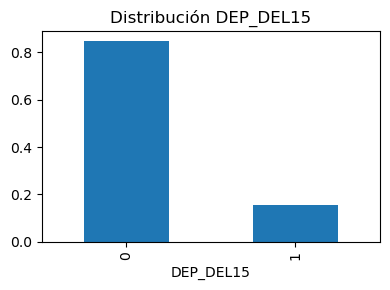

In [19]:
y = df0[TARGET].astype(int)
print(y.value_counts())
print("Delay rate:", y.mean())

plt.figure(figsize=(4,3))
y.value_counts(normalize=True).sort_index().plot(kind="bar")
plt.title("Distribución DEP_DEL15")
plt.tight_layout()
plt.show()

Métricas correctas para este caso: 
1. ROC-AUC
2. Recall. De todos los vuelos demorados, ¿cuántos detecta el modelo?
3. Precision. De los que el modelo predice como demorados, ¿cuántos realmente lo están?

### Efecto por tiempo: DAY_OF_WEEK y DEP_TIME_BLK

In [20]:
g = df0.groupby("DAY_OF_WEEK")[TARGET].agg(["mean","size"]).sort_index()
display(g)

,mean,size
DAY_OF_WEEK,,
1,0.155291,158477
2,0.131408,165720
3,0.138570,189630
4,0.164972,199476
5,0.162930,179378
6,0.171159,123680
7,0.159770,148870


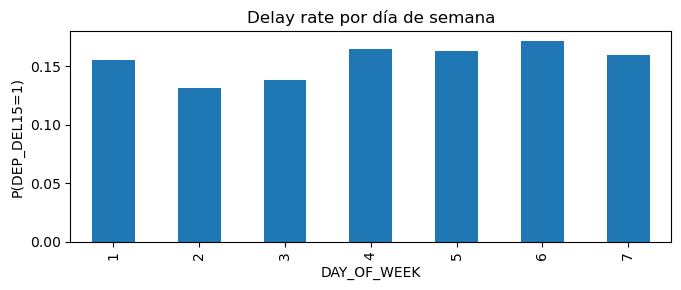

In [21]:
plt.figure(figsize=(7,3))
g["mean"].plot(kind="bar")
plt.title("Delay rate por día de semana")
plt.ylabel("P(DEP_DEL15=1)")
plt.tight_layout()
plt.show()

### Interpretación

Día 2 (probablemente martes, ya que la numeración es del 1 al 7, y en Python puro comienza en 0 (1 indica martes)) tiene menor tasa (aproximadamente 13%). Lo que puede indicar es que ese días no hay tantos vuelos, menor cantidad de vuelos de negocios, entre otros.

Día 6 (probablemente sábado) tiene mayor tasa (aproximadamente 17%). Mayor probabilidad de vuelos vacacionales.

El día de la semana presenta una asociación estadísticamente relevante con la probabilidad de demora, aunque no explica por sí solo el fenómeno.

In [22]:
g2 = df0.groupby("DEP_TIME_BLK")[TARGET].agg(["mean","size"]).sort_values("mean", ascending=False)
display(g2.head(20))

,mean,size
DEP_TIME_BLK,,
1900-1959,0.213067,63318
1800-1859,0.207463,67906
2000-2059,0.199745,54034
1700-1759,0.197012,75290
2100-2159,0.196444,35827
1600-1659,0.190533,69825
1400-1459,0.184387,70070
1500-1559,0.184260,70574
1300-1359,0.172020,66655


## Hallazgo clave: patrón monótono creciente

Desde las 06:00 hasta aproximadamente 19:00 hay:

Incremento casi monótono de la probabilidad de demora.

### Magnitud del efecto

1. 06:00 → 6.4%
2. 19:00 → 21.3%

21.3% − 6.4% = 14.9% -> Incremento absoluto

0.213 / 0.064 ≈ 3.3 --> Incremento relativo


Un vuelo a las 19:00 tiene más de 3 veces la probabilidad de demora que uno a las 06:00.

Se observa una dependencia temporal pronunciada en la probabilidad de demora.

La tasa aumenta progresivamente desde 6.4% en vuelos matutinos (06:00–06:59) hasta 21.3% en el bloque 19:00–19:59.

Este patrón es consistente con un fenómeno de acumulación de retrasos en sistemas con dependencia secuencial de recursos (rotación de aeronaves y slots aeroportuarios).

El efecto horario triplica el riesgo relativo de demora entre primeras horas del día y el pico vespertino.

### Carriers y aeropuertos: ranking con soporte

In [23]:
def rate_ci(p, n, z=1.96):
    # approx normal CI para proporción
    se = np.sqrt(p*(1-p)/n)
    return p - z*se, p + z*se

In [24]:
def segment_rates(col, min_n=2000, top=20):
    t = df0.groupby(col)[TARGET].agg(["mean","size"]).rename(columns={"mean":"rate","size":"n"})
    t = t[t["n"]>=min_n].copy()
    t["ci_lo"], t["ci_hi"] = zip(*t.apply(lambda r: rate_ci(r["rate"], r["n"]), axis=1))
    return t.sort_values("rate", ascending=False).head(top)

In [25]:
display(segment_rates("OP_CARRIER", min_n=2000, top=15))

,rate,n,ci_lo,ci_hi
OP_CARRIER,,,,
B6,0.208993,48016,0.205356,0.212630
G4,0.195305,14357,0.188821,0.201790
F9,0.193193,21802,0.187953,0.198434
MQ,0.182614,48994,0.179193,0.186035
OO,0.177724,131271,0.175656,0.179792
OH,0.171196,46368,0.167767,0.174624
EV,0.167523,22576,0.162652,0.172394
YV,0.160869,35302,0.157036,0.164702
AS,0.160173,40987,0.156622,0.163724


In [26]:
display(segment_rates("ORIGIN", min_n=3000, top=15))

,rate,n,ci_lo,ci_hi
ORIGIN,,,,
MDW,0.236003,11449,0.228225,0.243781
ORD,0.221176,48102,0.217467,0.224885
EWR,0.210280,21557,0.204840,0.215720
LGA,0.206717,27066,0.201892,0.211541
SFO,0.198675,26576,0.193878,0.203473
SJU,0.189059,4972,0.178175,0.199943
DFW,0.183974,46523,0.180453,0.187494
FLL,0.183612,17940,0.177946,0.189278
PBI,0.182296,5140,0.171741,0.192851


## Comparación: ¿Carrier o Aeropuerto pesa más?

Observación clave:

- Variación por carrier ≈ 14%–21%

- Variación por aeropuerto ≈ 16%–23%

La dispersión parece ligeramente mayor en ORIGIN.

El aeropuerto probablemente explica más varianza que la aerolínea.

## Interacciones: ORIGIN × DEP_TIME_BLK

In [27]:
min_n = 500
pivot = (df0.groupby(["ORIGIN","DEP_TIME_BLK"])[TARGET]
         .agg(["mean","size"])
         .reset_index())

pivot = pivot[pivot["size"]>=min_n]

# Top combos por tasa
top_combos = pivot.sort_values("mean", ascending=False).head(20)
display(top_combos)

,ORIGIN,DEP_TIME_BLK,mean,size
2435,MDW,1900-1959,0.375000,656
1271,EWR,2000-2059,0.374332,1496
1272,EWR,2100-2159,0.369898,1176
2436,MDW,2000-2059,0.355019,538
1270,EWR,1900-1959,0.341995,1193
2236,LGA,1900-1959,0.328481,1580
2237,LGA,2000-2059,0.324164,1345
2238,LGA,2100-2159,0.321627,1082
1269,EWR,1800-1859,0.312339,1556
2433,MDW,1700-1759,0.310403,596


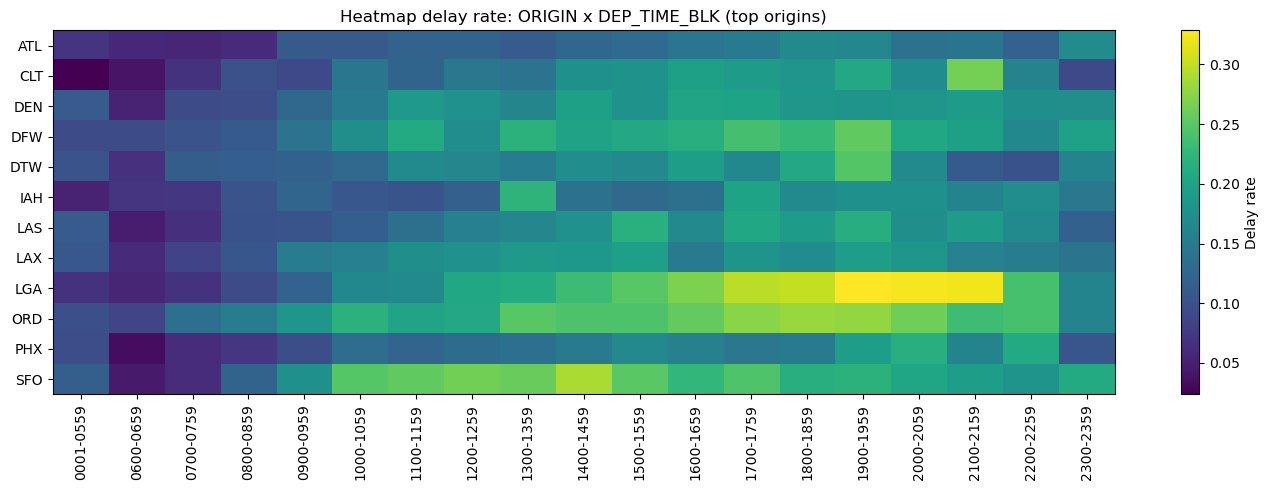

In [28]:
top_airports = df0["ORIGIN"].value_counts().head(12).index
sub = df0[df0["ORIGIN"].isin(top_airports)]

mat = (sub.groupby(["ORIGIN","DEP_TIME_BLK"])[TARGET]
       .mean()
       .unstack("DEP_TIME_BLK"))

plt.figure(figsize=(14,5))
plt.imshow(mat.fillna(mat.mean().mean()), aspect="auto")
plt.yticks(range(len(mat.index)), mat.index)
plt.xticks(range(len(mat.columns)), mat.columns, rotation=90)
plt.colorbar(label="Delay rate")
plt.title("Heatmap delay rate: ORIGIN x DEP_TIME_BLK (top origins)")
plt.tight_layout()
plt.show()

## Análisis

El análisis evidencia que:

El riesgo de demora no depende únicamente del aeropuerto o del horario por separado. Las combinaciones específicas de hubs congestionados en franjas nocturnas presentan riesgos extremadamente elevados (hasta 37%). Este patrón es consistente con la creencia de acumulación de retrasos durante el día.

La interacción aeropuerto–horario constituye uno de los factores más determinantes en la probabilidad de retraso.

In [29]:
## Se analiza si importa la distancia:

df0["DIST_BIN"] = pd.qcut(df0["DISTANCE"], q=10, duplicates="drop")
dist_rate = df0.groupby("DIST_BIN")[TARGET].agg(["mean","size"])
display(dist_rate)

,mean,size
DIST_BIN,,
"(30.999, 224.0]",0.147597,118065
"(224.0, 325.0]",0.148948,116846
"(325.0, 413.0]",0.145205,114776
"(413.0, 529.0]",0.146236,116490
"(529.0, 641.0]",0.148252,117017
"(641.0, 801.0]",0.165402,116879
"(801.0, 961.0]",0.152857,115598
"(961.0, 1145.0]",0.167646,117080
"(1145.0, 1605.0]",0.160720,116781


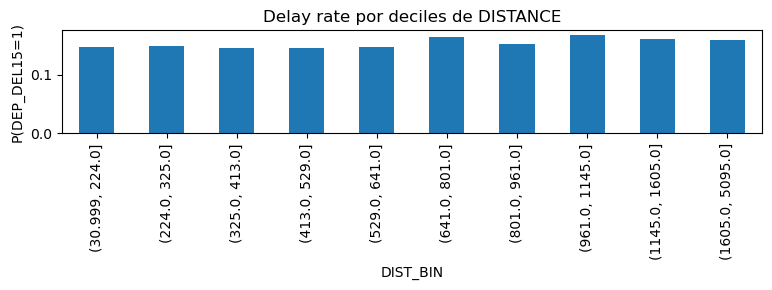

In [30]:
plt.figure(figsize=(8,3))
dist_rate["mean"].plot(kind="bar")
plt.title("Delay rate por deciles de DISTANCE")
plt.ylabel("P(DEP_DEL15=1)")
plt.tight_layout()
plt.show()

# DISTANCE no es un driver fuerte de demoras

DISTANCE tiene un efecto marginal débil y no monotónico sobre la probabilidad de demora de salida.

In [31]:
def target_encode_cv(
    X: pd.DataFrame,
    y: pd.Series,
    cols: list[str],
    n_splits: int = 5,
    seed: int = 42,
    smoothing: float = 50.0,
    noise: float = 0.0,
    handle_unknown: str = "global_mean",
):
    if isinstance(y, pd.DataFrame):
        y = y.iloc[:, 0]
    y = y.astype(float)
    X_te = X.copy()

    global_mean = float(y.mean())
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)

    oof_encoded = {c: pd.Series(index=X.index, dtype=float) for c in cols}

    for tr_idx, va_idx in skf.split(X, y):
        X_tr, y_tr = X.iloc[tr_idx], y.iloc[tr_idx]
        X_va = X.iloc[va_idx]

        for c in cols:
            stats = (
                pd.DataFrame({c: X_tr[c], "y": y_tr})
                .groupby(c)["y"]
                .agg(["sum", "count"])
            )
            te_map = (stats["sum"] + smoothing * global_mean) / (stats["count"] + smoothing)

            enc = X_va[c].map(te_map)

            if handle_unknown == "global_mean":
                enc = enc.fillna(global_mean)
            elif handle_unknown == "nan":
                pass
            else:
                raise ValueError("handle_unknown debe ser 'global_mean' o 'nan'")

            if noise and noise > 0:
                enc = enc + np.random.normal(0, noise, size=len(enc))

            oof_encoded[c].iloc[va_idx] = enc.values

    for c in cols:
        X_te[f"{c}__te"] = oof_encoded[c].astype(float)

    mappings = {}
    for c in cols:
        stats_full = pd.DataFrame({c: X[c], "y": y}).groupby(c)["y"].agg(["sum", "count"])
        te_map_full = (stats_full["sum"] + smoothing * global_mean) / (stats_full["count"] + smoothing)
        mappings[c] = te_map_full

    state = {
        "global_mean": global_mean,
        "mappings": mappings,
        "cols": cols,
        "smoothing": smoothing,
        "handle_unknown": handle_unknown,
    }
    return X_te, state

In [32]:
def target_encode_transform(X, state):
    X_out = X.copy()
    global_mean = state["global_mean"]
    mappings = state["mappings"]
    cols = state["cols"]
    handle_unknown = state["handle_unknown"]

    for c in cols:
        enc = X_out[c].map(mappings[c])
        if handle_unknown == "global_mean":
            enc = enc.fillna(global_mean)
        X_out[f"{c}__te"] = enc.astype(float)

    return X_out

In [33]:
TARGET = "DEP_DEL15"

cat_cols = ["OP_CARRIER", "ORIGIN", "DEST", "DEP_TIME_BLK", "DAY_OF_WEEK", "DAY_OF_MONTH"]
num_cols = ["DISTANCE"]

X = df0[cat_cols + num_cols].copy()
y = df0[TARGET].astype(int)

# Target Encoding: categóricas con señal y/o alta cardinalidad
te_cols = ["ORIGIN", "DEST", "OP_CARRIER", "DEP_TIME_BLK"]

In [34]:
# Split estratificado
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [35]:
# Aplicaamos Target Encoding (OOF en train, mapping en test)
X_train_te, te_state = target_encode_cv(
    X_train, y_train,
    cols=te_cols,
    n_splits=5,
    seed=42,
    smoothing=50.0,
    noise=0.0,
    handle_unknown="global_mean"
)

X_test_te = target_encode_transform(X_test, te_state)

# Eliminamos columnas categóricas originales que ya fueron TE-adas
X_train_model = X_train_te.drop(columns=te_cols)
X_test_model  = X_test_te.drop(columns=te_cols)

In [36]:
# Se calcula F1-measure
def pick_threshold_by_f1(y_true, proba):
    prec, rec, thr = precision_recall_curve(y_true, proba)
    f1 = 2 * (prec * rec) / (prec + rec + 1e-12)
    best = np.nanargmax(f1)
    # thr tiene len = len(prec)-1
    best_thr = thr[max(best-1, 0)] if len(thr) else 0.5
    return best_thr, prec[best], rec[best], f1[best]

In [37]:
def pick_threshold_for_recall(y_true, proba, target_recall=0.70):
    
    prec, rec, thr = precision_recall_curve(y_true, proba)
    
    # rec está en orden descendente; buscamos primer punto con rec>=target
    
    idx = np.where(rec >= target_recall)[0]
    
    if len(idx) == 0:
        
        return 0.5, prec[-1], rec[-1]
        
    i = idx[-1]  # más conservador (mayor threshold) manteniendo recall
    
    best_thr = thr[max(i-1, 0)] if len(thr) else 0.5
    
    return best_thr, prec[i], rec[i]

# Se aplica Logistic Regression

In [38]:
logreg = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        solver="lbfgs",
        n_jobs=None
    ))
])

In [39]:
logreg.fit(X_train_model, y_train)

proba_lr = logreg.predict_proba(X_test_model)[:, 1]

print("LogReg ROC-AUC:", roc_auc_score(y_test, proba_lr))
print("LogReg PR-AUC :", average_precision_score(y_test, proba_lr))

LogReg ROC-AUC: 0.6398240387479412
LogReg PR-AUC : 0.23432397476432004


In [40]:
thr_lr, p_lr, r_lr, f1_lr = pick_threshold_by_f1(y_test, proba_lr)
print(f"Best F1 threshold={thr_lr:.3f} | precision={p_lr:.3f} recall={r_lr:.3f} f1={f1_lr:.3f}")

pred_lr = (proba_lr >= thr_lr).astype(int)
print("\nConfusion matrix (LogReg):\n", confusion_matrix(y_test, pred_lr))
print("\nReport (LogReg):\n", classification_report(y_test, pred_lr, digits=3))

Best F1 threshold=0.505 | precision=0.212 recall=0.620 f1=0.316

Confusion matrix (LogReg):
 [[114284  82812]
 [ 13661  22290]]

Report (LogReg):
               precision    recall  f1-score   support

           0      0.893     0.580     0.703    197096
           1      0.212     0.620     0.316     35951

    accuracy                          0.586    233047
   macro avg      0.553     0.600     0.510    233047
weighted avg      0.788     0.586     0.643    233047



# Random Forest

In [41]:
rf = RandomForestClassifier(
    n_estimators=400,
    max_depth=None,
    min_samples_leaf=50,       # importantísimo para no sobreajustar categorías TE
    min_samples_split=200,
    max_features="sqrt",
    class_weight="balanced_subsample",
    n_jobs=-1,
    random_state=42
)

rf.fit(X_train_model, y_train)

proba_rf = rf.predict_proba(X_test_model)[:, 1]

print("RF ROC-AUC:", roc_auc_score(y_test, proba_rf))
print("RF PR-AUC :", average_precision_score(y_test, proba_rf))

RF ROC-AUC: 0.7030739666005306
RF PR-AUC : 0.34009654881438084


In [42]:
thr_rf, p_rf, r_rf, f1_rf = pick_threshold_by_f1(y_test, proba_rf)
print(f"Best F1 threshold={thr_rf:.3f} | precision={p_rf:.3f} recall={r_rf:.3f} f1={f1_rf:.3f}")

pred_rf = (proba_rf >= thr_rf).astype(int)
print("\nConfusion matrix (RF):\n", confusion_matrix(y_test, pred_rf))
print("\nReport (RF):\n", classification_report(y_test, pred_rf, digits=3))

Best F1 threshold=0.534 | precision=0.288 recall=0.503 f1=0.366

Confusion matrix (RF):
 [[152398  44698]
 [ 17885  18066]]

Report (RF):
               precision    recall  f1-score   support

           0      0.895     0.773     0.830    197096
           1      0.288     0.503     0.366     35951

    accuracy                          0.731    233047
   macro avg      0.591     0.638     0.598    233047
weighted avg      0.801     0.731     0.758    233047



## Feature importance de RF

In [43]:
importances = pd.Series(rf.feature_importances_, index=X_train_model.columns).sort_values(ascending=False)
display(importances.head(20))

DEP_TIME_BLK__te    0.259454
ORIGIN__te          0.159174
DAY_OF_MONTH        0.150323
DEST__te            0.144554
OP_CARRIER__te      0.122425
DISTANCE            0.094949
DAY_OF_WEEK         0.069121
dtype: float64

## Análisis

La mejora de 0.64 → 0.70 (de LR a RF) en ROC-AUC es importante

La mejora de 0.23 → 0.34 (de LR a RF) en PR-AUC es aún más importante. Random Forest captura heterogeneidad espacial y temporal mejor.

## Aplicamos GridSearch al modelo de Regresión Logística

In [44]:
param_grid_lr = {
    "C": [0.05, 0.1, 0.3, 1, 3, 10],
    "penalty": ["l2"],
    "solver": ["lbfgs"],
    "class_weight": ["balanced"],
    "max_iter": [3000]
}

logreg = LogisticRegression()

gs_lr = GridSearchCV(
    estimator=logreg,
    param_grid=param_grid_lr,
    scoring="average_precision",  # PR-AUC
    cv=5,
    n_jobs=-1,
    verbose=2
)

gs_lr.fit(X_train_model, y_train)

print("Best LR params:", gs_lr.best_params_)
print("Best LR CV PR-AUC:", gs_lr.best_score_)

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best LR params: {'C': 0.05, 'class_weight': 'balanced', 'max_iter': 3000, 'penalty': 'l2', 'solver': 'lbfgs'}
Best LR CV PR-AUC: 0.23569297233260117


In [45]:
# Evaluamos en test
best_lr = gs_lr.best_estimator_
proba_lr = best_lr.predict_proba(X_test_model)[:,1]

from sklearn.metrics import roc_auc_score, average_precision_score

print("TEST LR ROC-AUC:", roc_auc_score(y_test, proba_lr))
print("TEST LR PR-AUC :", average_precision_score(y_test, proba_lr))

TEST LR ROC-AUC: 0.6397532206158074
TEST LR PR-AUC : 0.23437990555967414


## GridSearch para Random Forest

In [46]:
from scipy.stats import randint

In [47]:
param_dist_rf = {
    "n_estimators": [300, 400, 600],
    "max_depth": [None, 12, 15, 20, 25],
    "min_samples_leaf": [20, 50, 100],
    "min_samples_split": [100, 200, 400, 800],
    "max_features": ["sqrt", 0.5],
    "class_weight": ["balanced_subsample"],
    "bootstrap": [True],          # RF default, lo dejamos fijo
}

rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

rs_rf = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist_rf,
    n_iter=30,                    # 30–50
    scoring="average_precision",  # PR-AUC
    cv=5,                         # CV=5 por costo (con 1M+ filas)
    n_jobs=-1,
    verbose=2,
    random_state=42
)

rs_rf.fit(X_train_model, y_train)

print("Best RF params:", rs_rf.best_params_)
print("Best RF CV PR-AUC:", rs_rf.best_score_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best RF params: {'n_estimators': 400, 'min_samples_split': 100, 'min_samples_leaf': 20, 'max_features': 0.5, 'max_depth': 25, 'class_weight': 'balanced_subsample', 'bootstrap': True}
Best RF CV PR-AUC: 0.35364005219145894


In [48]:
best_rf = rs_rf.best_estimator_
proba_rf = best_rf.predict_proba(X_test_model)[:, 1]

print("TEST RF ROC-AUC:", roc_auc_score(y_test, proba_rf))
print("TEST RF PR-AUC :", average_precision_score(y_test, proba_rf))

TEST RF ROC-AUC: 0.7116034754117139
TEST RF PR-AUC : 0.36374468989391046


# Generar curvas PR

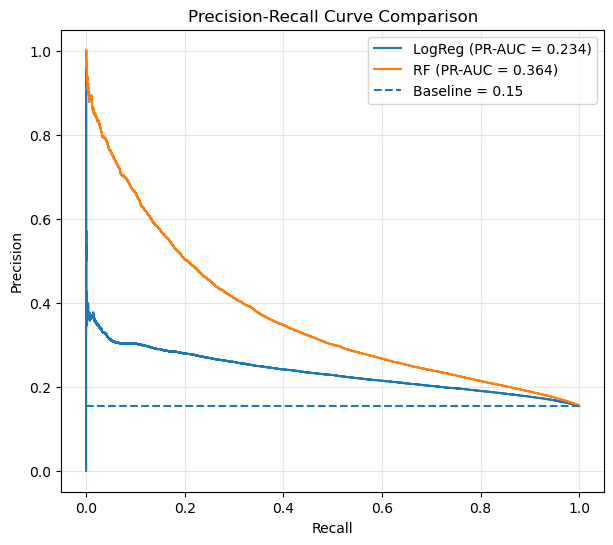

In [50]:
# Curva LR
prec_lr, rec_lr, _ = precision_recall_curve(y_test, proba_lr)
pr_auc_lr = average_precision_score(y_test, proba_lr)

# Curva RF
prec_rf, rec_rf, _ = precision_recall_curve(y_test, proba_rf)
pr_auc_rf = average_precision_score(y_test, proba_rf)

# Baseline
baseline = y_test.mean()

plt.figure(figsize=(7,6))
plt.plot(rec_lr, prec_lr, label=f"LogReg (PR-AUC = {pr_auc_lr:.3f})")
plt.plot(rec_rf, prec_rf, label=f"RF (PR-AUC = {pr_auc_rf:.3f})")

plt.hlines(baseline, 0, 1, linestyles="dashed", label=f"Baseline = {baseline:.2f}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Se analizará precision a recall fijo

In [51]:
def precision_at_recall(precision, recall, target_recall=0.7):
    idx = (recall >= target_recall)
    if idx.sum() == 0:
        return None
    return precision[idx][-1]

In [52]:
print("LR precision @ 0.7 recall:", precision_at_recall(prec_lr, rec_lr, 0.7))
print("RF precision @ 0.7 recall:", precision_at_recall(prec_rf, rec_rf, 0.7))

LR precision @ 0.7 recall: 0.20186577041237858
RF precision @ 0.7 recall: 0.23917051567162761


# Conclusion

El modelo Random Forest muestra una mejora notable respecto a la regresión logística tanto en PR-AUC (0.364 vs 0.234) como en precision a recall fijo (0.239 vs 0.202 @ recall=0.7). Esto indica que las demoras de vuelos presentan patrones no lineales e interacciones complejas entre variables categóricas de alta cardinalidad (aeropuerto, carrier, horario), que no son adecuadamente capturados por modelos lineales.